In [1]:
# =============================================================================
# Deep Learning Pipeline – Gym Movements Dataset
# Models: TCN, LSTM, CNN-LSTM
# Evaluation: Mixed session-based k-fold (both participants in every fold)
# Features: raw acc/gyro + gravity-aligned channels (orientation-invariant)
# =============================================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from Python.integrations import load_gym_dataset
from Python.windows import create_adaptive_windows
from Python.posthoc import ML4QSFlexiblePipeline

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

In [2]:
# ── 1. LOAD DATA ─────────────────────────────────────────────────────────────
print("Loading Gym Movements Dataset...")
raw_data = load_gym_dataset(Path("./Datasets/cropped"))

print(f"\nTotal samples  : {len(raw_data):,}")
print(f"Participants   : {sorted(raw_data['participant'].unique())}")
print(f"Activities     : {sorted(raw_data['activity_label'].unique())}")
print(f"Sessions/person: {raw_data.groupby('participant')['session'].nunique().to_dict()}")
print(f"Columns        : {list(raw_data.columns)}")
raw_data.head(3)

Loading Gym Movements Dataset...
Gym Movements Dataset loaded:
  Total samples : 175,573
  Participants  : ['imaan', 'richard']
  Activities    : ['elliptical', 'lat_pull', 'lunge', 'row', 'threadmill']
  Sessions      : 74
  Columns       : ['time', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'grav_x', 'grav_y', 'grav_z', 'orient_qz', 'orient_qy', 'orient_qx', 'orient_qw', 'orient_roll', 'orient_pitch', 'orient_yaw', 'magnet_x', 'magnet_y', 'magnet_z', 'acc_vert', 'acc_horiz', 'gyro_vert', 'gyro_horiz', 'activity_label', 'participant', 'session', 'data_source']

Total samples  : 175,573
Participants   : ['imaan', 'richard']
Activities     : ['elliptical', 'lat_pull', 'lunge', 'row', 'threadmill']
Sessions/person: {'imaan': 48, 'richard': 26}
Columns        : ['time', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'grav_x', 'grav_y', 'grav_z', 'orient_qz', 'orient_qy', 'orient_qx', 'orient_qw', 'orient_roll', 'orient_pitch', 'orient_yaw', 'magnet_x', 'magnet_y', 

,time,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,grav_x,grav_y,grav_z,...,magnet_y,magnet_z,acc_vert,acc_horiz,gyro_vert,gyro_horiz,activity_label,participant,session,data_source
0,0.000000,0.173412,-1.01202,0.230539,-0.707987,-0.479600,1.101513,-0.662412,-3.447979,9.149461,...,28.106251,-35.343750,0.559578,0.891222,1.244987,0.628171,elliptical,imaan,0,original
1,0.019519,0.240469,-1.24172,0.357223,-0.643775,-0.588225,1.202713,-0.647469,-3.455279,9.147778,...,27.018751,-38.737503,0.755366,1.075511,1.372597,0.568286,elliptical,imaan,0,original
2,0.039040,0.269452,-1.34355,0.356299,-0.576950,-0.688187,1.316975,-0.638452,-3.462449,9.145700,...,27.693750,-37.425003,0.789647,1.175218,1.509778,0.511338,elliptical,imaan,0,original


In [3]:
# ── 2. MISSING VALUE HANDLING ─────────────────────────────────────────────────
SENSOR_COLS = [
    "acc_x", "acc_y", "acc_z",
    "gyro_x", "gyro_y", "gyro_z",
    "grav_x", "grav_y", "grav_z",
    "magnet_x", "magnet_y", "magnet_z",
    "acc_vert", "acc_horiz", "gyro_vert", "gyro_horiz",
]

missing = raw_data[SENSOR_COLS].isnull().sum()
total_missing = int(missing.sum())
print(f"Total missing sensor readings: {total_missing}")

if total_missing > 0:
    print("Applying linear interpolation per (participant, session)...")
    raw_data[SENSOR_COLS] = (
        raw_data.groupby(["participant", "session"])[SENSOR_COLS]
        .transform(lambda g: g.interpolate(method="linear").ffill().bfill())
    )
    print(f"Remaining missing: {int(raw_data[SENSOR_COLS].isnull().sum().sum())}")
else:
    print("No missing values — dataset is complete.")

Total missing sensor readings: 63
Applying linear interpolation per (participant, session)...
Remaining missing: 0


In [4]:
# ── 3. WINDOWING ──────────────────────────────────────────────────────────────
windowed_data = create_adaptive_windows(
    raw_data,
    min_window_size=64,
    preferred_window_size=128,   # 2.56 s @ 50 Hz
    overlap_ratio=0.5,
)


Window creation summary:
  Full-size windows: 2633
  Adaptive windows: 0
  Rejected segments: 0
  Total windows: 2633


In [5]:
# ── 4. PREPARE SEQUENCES ──────────────────────────────────────────────────────
# Channels: acc_x/y/z, gyro_x/y/z + gravity-aligned acc_vert, acc_horiz,
# gyro_vert, gyro_horiz  →  10 channels total (orientation-invariant)

pipeline = ML4QSFlexiblePipeline(sampling_rate=50, window_size=128)

sequences, labels, metadata = pipeline.prepare_sequences(windowed_data)
participants = [m["participant"] for m in metadata]
sessions     = [m["session"]     for m in metadata]

print(f"Sequences shape : {sequences.shape}")
print(f"  (N windows, timesteps, channels)")
print(f"Gravity-aligned channels included: {sequences.shape[2] > 6}")
print(f"Label distribution: {dict(zip(*np.unique(labels, return_counts=True)))}")
print(f"Windows per participant: {dict(zip(*np.unique(participants, return_counts=True)))}")

Sequences shape : (2633, 128, 10)
  (N windows, timesteps, channels)
Gravity-aligned channels included: True
Label distribution: {np.str_('elliptical'): np.int64(984), np.str_('lat_pull'): np.int64(506), np.str_('lunge'): np.int64(100), np.str_('row'): np.int64(393), np.str_('threadmill'): np.int64(650)}
Windows per participant: {np.str_('imaan'): np.int64(1042), np.str_('richard'): np.int64(1591)}



Mixed-LOSO (5 folds), participants: ['imaan', 'richard']
Classes (5): [np.str_('elliptical'), np.str_('lat_pull'), np.str_('lunge'), np.str_('row'), np.str_('threadmill')]

Mixed-LOSO fold 1/5: test participants=[np.str_('imaan'), np.str_('richard')]
Train samples: 2026, Test samples: 607
  Class weights: {np.str_('elliptical'): '0.55', np.str_('lat_pull'): '0.91', np.str_('lunge'): '5.30', np.str_('row'): '1.33', np.str_('threadmill'): '0.87'}

Training TCN (fold 1)...
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8885 - loss: 0.4513 - val_accuracy: 0.8454 - val_loss: 0.5418 - learning_rate: 0.0010
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9750 - loss: 0.0835 - val_accuracy: 0.9770 - val_loss: 0.1427 - learning_rate: 0.0010
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9855 - loss: 0.0624 - val_accuracy: 0.9770 - val_loss: 0.1029 - learning_rate: 0.0010
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9762 -

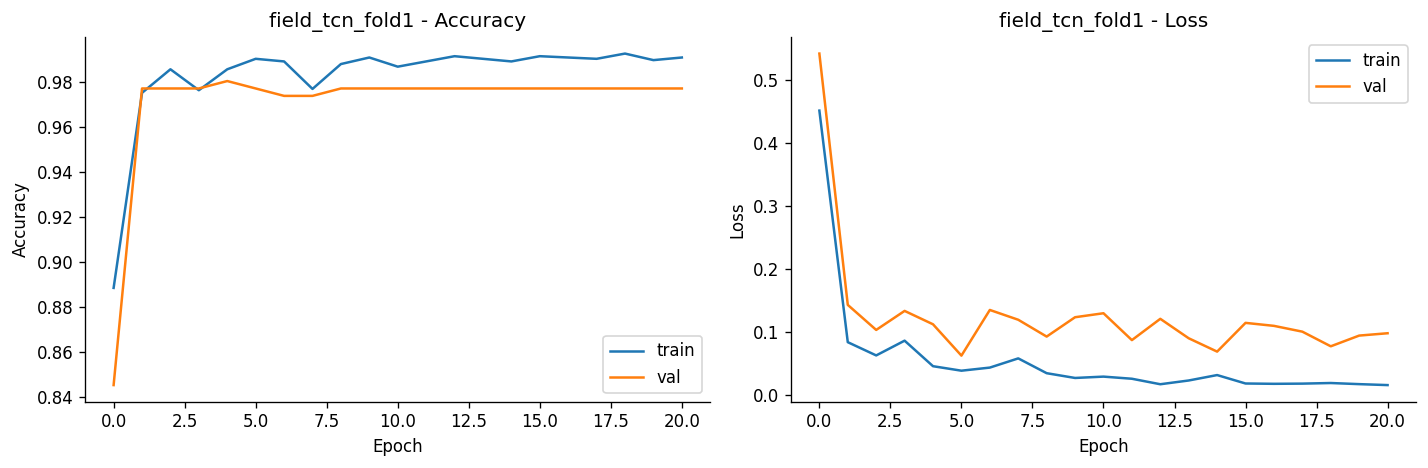


Training LSTM (fold 1)...
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.5505 - loss: 1.2037 - val_accuracy: 0.7401 - val_loss: 0.6241 - learning_rate: 0.0010
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7909 - loss: 0.5853 - val_accuracy: 0.6809 - val_loss: 0.6737 - learning_rate: 0.0010
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8821 - loss: 0.3531 - val_accuracy: 0.7467 - val_loss: 0.7041 - learning_rate: 0.0010
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8380 - loss: 0.4002 - val_accuracy: 0.9046 - val_loss: 0.2987 - learning_rate: 0.0010
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9082 - loss: 0.3241 - val_accuracy: 0.9441 - val_loss: 0.2759 - learning_rate: 0.0010
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9715 - loss: 0.1453 - val_accuracy: 0.9474 - val_loss: 0.2372 - learning_rate: 0.0010
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.97

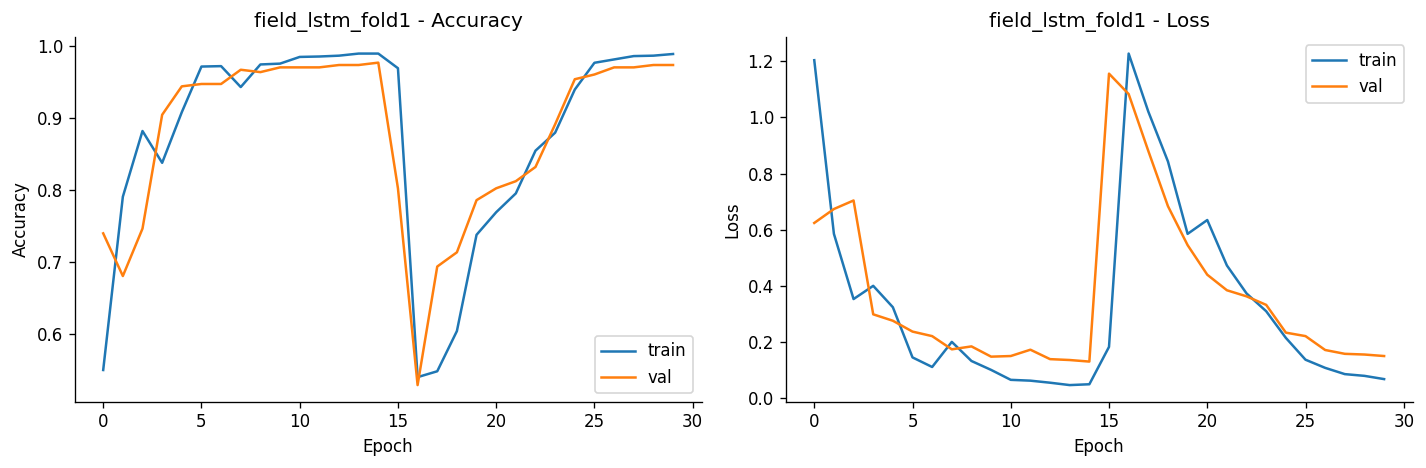


Training CNN_LSTM (fold 1)...
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4936 - loss: 1.2782 - val_accuracy: 0.6974 - val_loss: 0.9149 - learning_rate: 0.0010
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9071 - loss: 0.3880 - val_accuracy: 0.7500 - val_loss: 1.2979 - learning_rate: 0.0010
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9744 - loss: 0.1193 - val_accuracy: 0.9441 - val_loss: 0.3269 - learning_rate: 0.0010
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9739 - loss: 0.1096 - val_accuracy: 0.9572 - val_loss: 0.1826 - learning_rate: 0.0010
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9849 - loss: 0.0645 - val_accuracy: 0.9572 - val_loss: 0.2029 - learning_rate: 0.0010
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9762 - loss: 0.1318 - val_accuracy: 0.9671 - val_loss: 0.1304 - learning_rate: 0.0010
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 

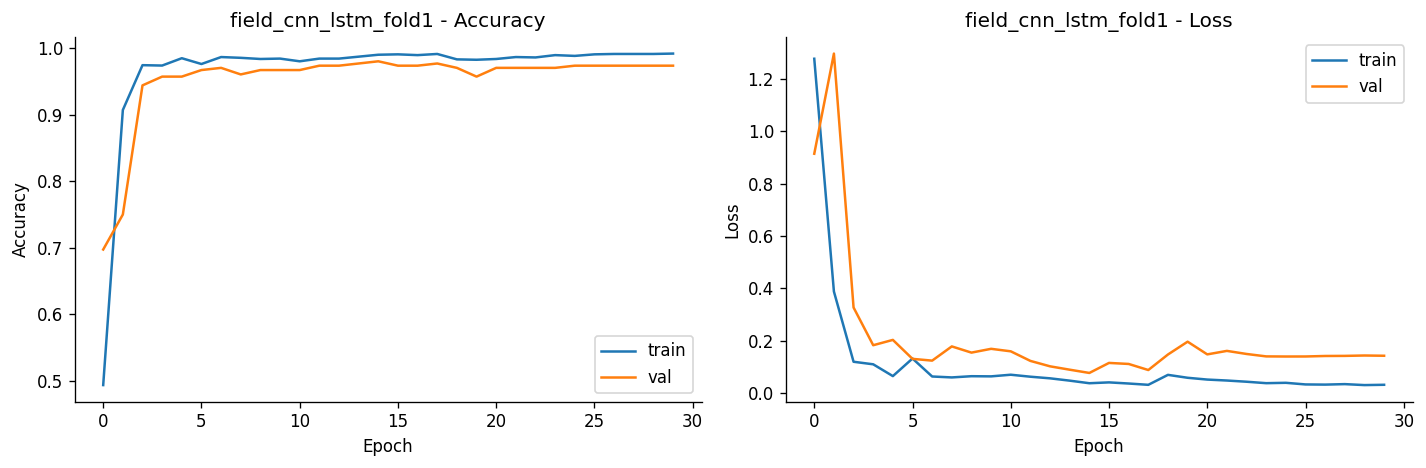


Mixed-LOSO fold 2/5: test participants=[np.str_('imaan'), np.str_('richard')]
Train samples: 2131, Test samples: 502
  Class weights: {np.str_('elliptical'): '0.59', np.str_('lat_pull'): '1.00', np.str_('lunge'): '5.57', np.str_('row'): '1.37', np.str_('threadmill'): '0.72'}

Training TCN (fold 2)...
Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8758 - loss: 0.3384 - val_accuracy: 0.9500 - val_loss: 0.2864 - learning_rate: 0.0010
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9752 - loss: 0.0597 - val_accuracy: 0.8687 - val_loss: 0.4339 - learning_rate: 0.0010
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9818 - loss: 0.0439 - val_accuracy: 0.8844 - val_loss: 0.4894 - learning_rate: 0.0010
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9829 - loss: 0.0347 - val_accuracy: 0.9312 - val_loss: 0.1713 - learning_rate: 0.0010
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9862 - loss: 0.0382 - val_ac

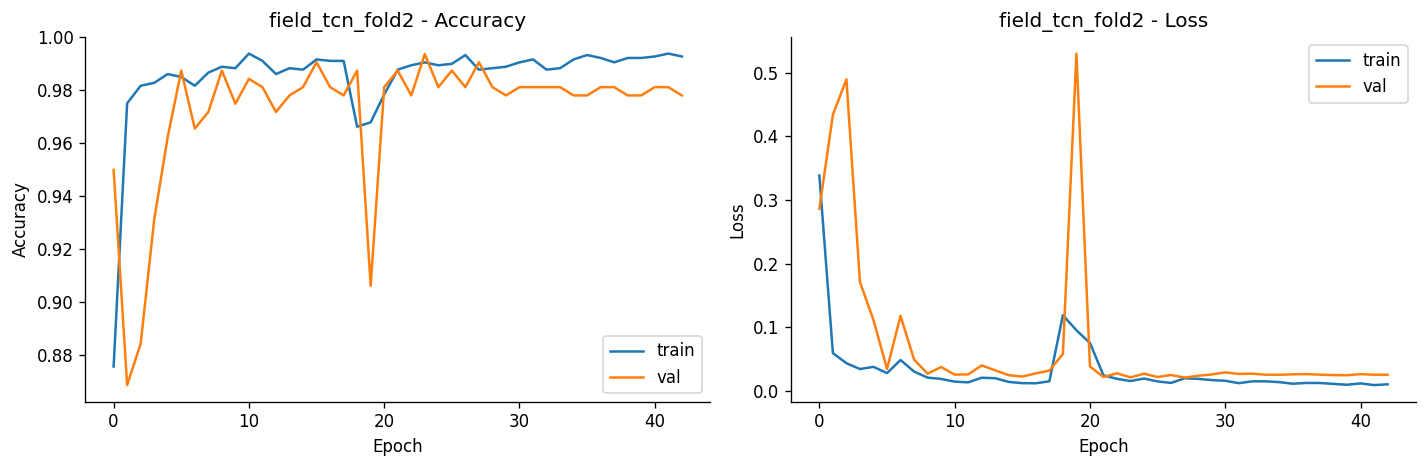


Training LSTM (fold 2)...
Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.4832 - loss: 1.2885 - val_accuracy: 0.7469 - val_loss: 0.7340 - learning_rate: 0.0010
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7835 - loss: 0.6710 - val_accuracy: 0.7969 - val_loss: 0.3391 - learning_rate: 0.0010
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7858 - loss: 0.5177 - val_accuracy: 0.8313 - val_loss: 0.3382 - learning_rate: 0.0010
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.7118 - loss: 0.7055 - val_accuracy: 0.7031 - val_loss: 0.6115 - learning_rate: 0.0010
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7443 - loss: 0.6138 - val_accuracy: 0.6687 - val_loss: 0.8171 - learning_rate: 0.0010
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7764 - loss: 0.5784 - val_accuracy: 0.7812 - val_loss: 0.5388 - learning_rate: 0.0010
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.80

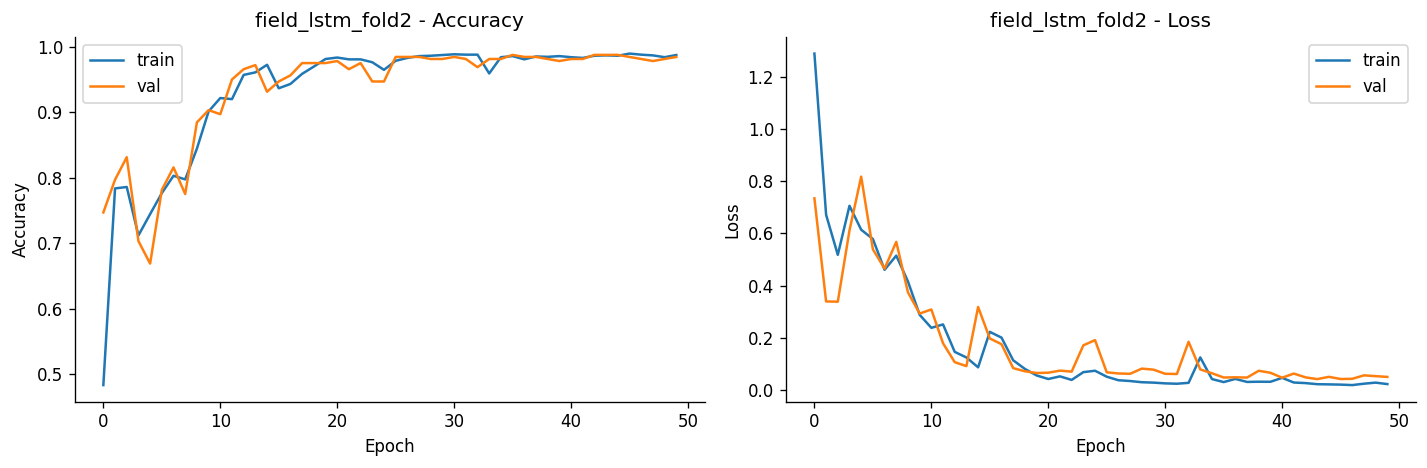


Training CNN_LSTM (fold 2)...
Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5781 - loss: 1.2061 - val_accuracy: 0.7500 - val_loss: 0.7591 - learning_rate: 0.0010
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9277 - loss: 0.3395 - val_accuracy: 0.8375 - val_loss: 0.8315 - learning_rate: 0.0010
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9757 - loss: 0.1014 - val_accuracy: 0.9594 - val_loss: 0.1704 - learning_rate: 0.0010
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9707 - loss: 0.0968 - val_accuracy: 0.9656 - val_loss: 0.1331 - learning_rate: 0.0010
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9752 - loss: 0.0822 - val_accuracy: 0.9688 - val_loss: 0.0878 - learning_rate: 0.0010
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9812 - loss: 0.0493 - val_accuracy: 0.9844 - val_loss: 0.0538 - learning_rate: 0.0010
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 

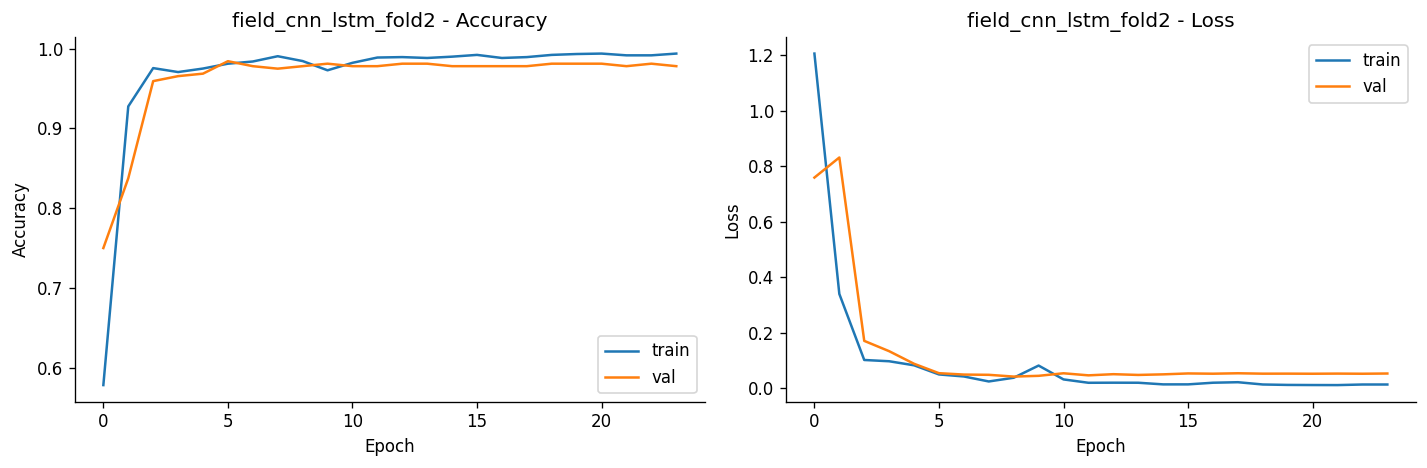


Mixed-LOSO fold 3/5: test participants=[np.str_('imaan'), np.str_('richard')]
Train samples: 2175, Test samples: 458
  Class weights: {np.str_('elliptical'): '0.52', np.str_('lat_pull'): '1.18', np.str_('lunge'): '5.78', np.str_('row'): '1.37', np.str_('threadmill'): '0.75'}

Training TCN (fold 3)...
Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8561 - loss: 0.4344 - val_accuracy: 0.9572 - val_loss: 0.2727 - learning_rate: 0.0010
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9665 - loss: 0.0963 - val_accuracy: 0.9878 - val_loss: 0.0824 - learning_rate: 0.0010
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9773 - loss: 0.0696 - val_accuracy: 0.9725 - val_loss: 0.0897 - learning_rate: 0.0010
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9719 - loss: 0.0717 - val_accuracy: 0.9327 - val_loss: 0.1980 - learning_rate: 0.0010
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9702 - loss: 0.0707 - val_ac

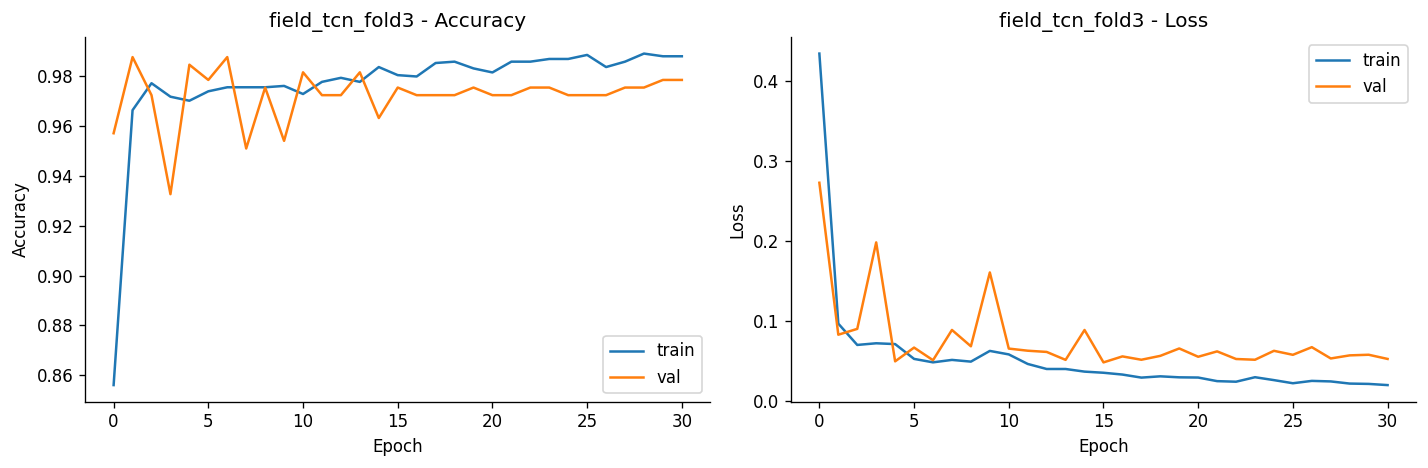


Training LSTM (fold 3)...
Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.5622 - loss: 1.2841 - val_accuracy: 0.6422 - val_loss: 1.0018 - learning_rate: 0.0010
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.7700 - loss: 0.7303 - val_accuracy: 0.8226 - val_loss: 0.3766 - learning_rate: 0.0010
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.8485 - loss: 0.4792 - val_accuracy: 0.8012 - val_loss: 0.3760 - learning_rate: 0.0010
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.8263 - loss: 0.4166 - val_accuracy: 0.8532 - val_loss: 0.3316 - learning_rate: 0.0010
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.7890 - loss: 0.6322 - val_accuracy: 0.8930 - val_loss: 0.3473 - learning_rate: 0.0010
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.7944 - loss: 0.5242 - val_accuracy: 0.7615 - val_loss: 0.6231 - learning_rate: 0.0010
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.79

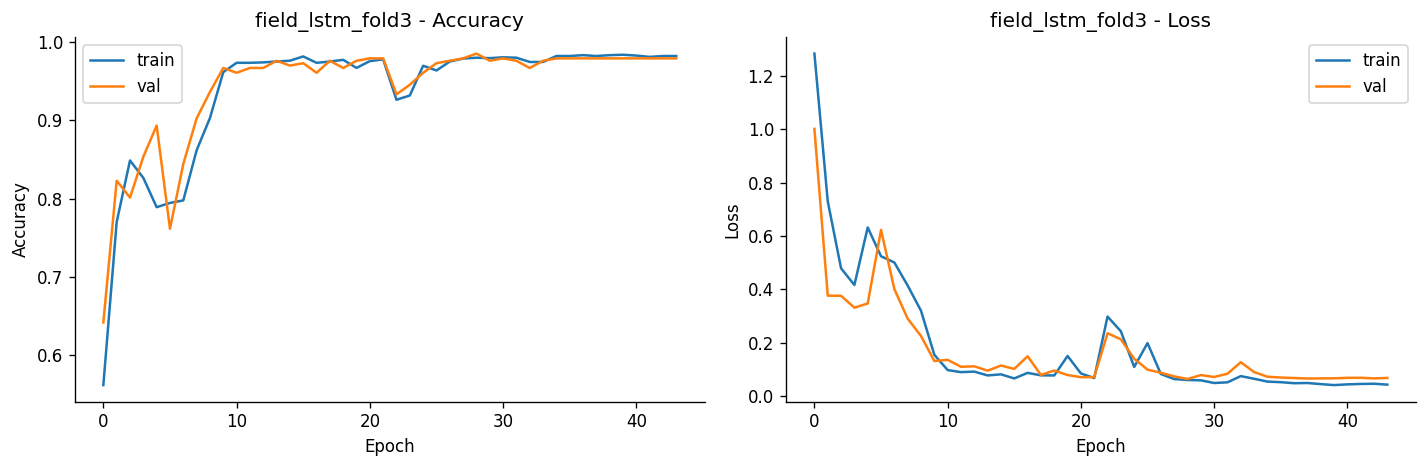


Training CNN_LSTM (fold 3)...
Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6759 - loss: 1.1774 - val_accuracy: 0.8012 - val_loss: 0.8571 - learning_rate: 0.0010
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9286 - loss: 0.3002 - val_accuracy: 0.9602 - val_loss: 0.1861 - learning_rate: 0.0010
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9535 - loss: 0.1539 - val_accuracy: 0.9755 - val_loss: 0.1031 - learning_rate: 0.0010
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9670 - loss: 0.1120 - val_accuracy: 0.9358 - val_loss: 0.3049 - learning_rate: 0.0010
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9659 - loss: 0.1089 - val_accuracy: 0.9786 - val_loss: 0.0966 - learning_rate: 0.0010
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9751 - loss: 0.0793 - val_accuracy: 0.9694 - val_loss: 0.1041 - learning_rate: 0.0010
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 

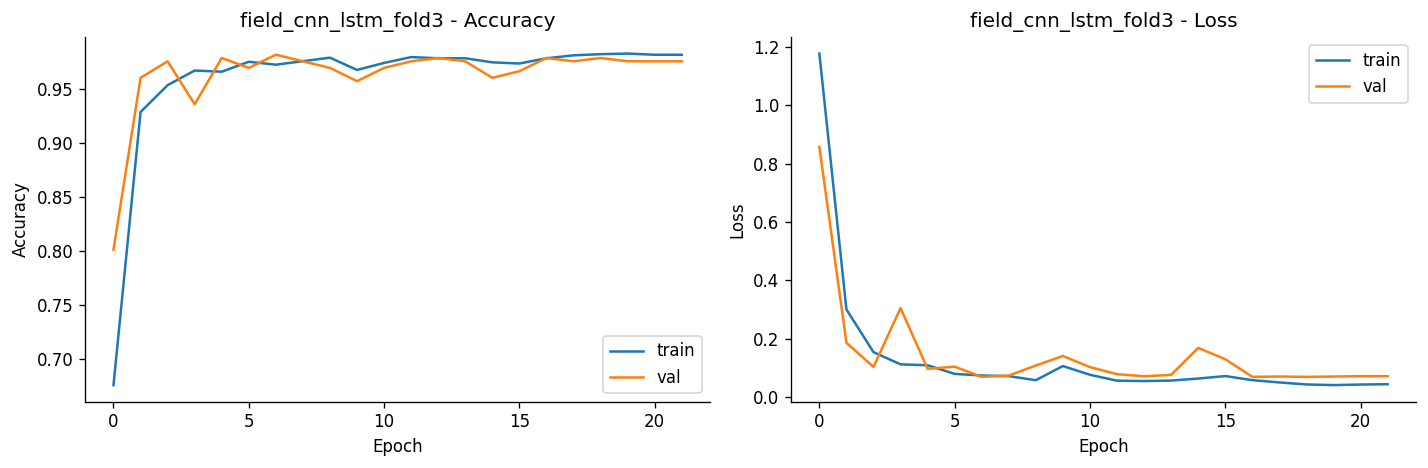


Mixed-LOSO fold 4/5: test participants=[np.str_('imaan'), np.str_('richard')]
Train samples: 2079, Test samples: 554
  Class weights: {np.str_('elliptical'): '0.52', np.str_('lat_pull'): '1.11', np.str_('lunge'): '5.70', np.str_('row'): '1.21', np.str_('threadmill'): '0.85'}

Training TCN (fold 4)...
Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8664 - loss: 0.4060 - val_accuracy: 0.8045 - val_loss: 0.7088 - learning_rate: 0.0010
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9717 - loss: 0.0976 - val_accuracy: 0.9551 - val_loss: 0.1920 - learning_rate: 0.0010
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9762 - loss: 0.0815 - val_accuracy: 0.9071 - val_loss: 0.3008 - learning_rate: 0.0010
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9723 - loss: 0.0914 - val_accuracy: 0.9615 - val_loss: 0.1313 - learning_rate: 0.0010
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9751 - loss: 0.0754 - val_ac

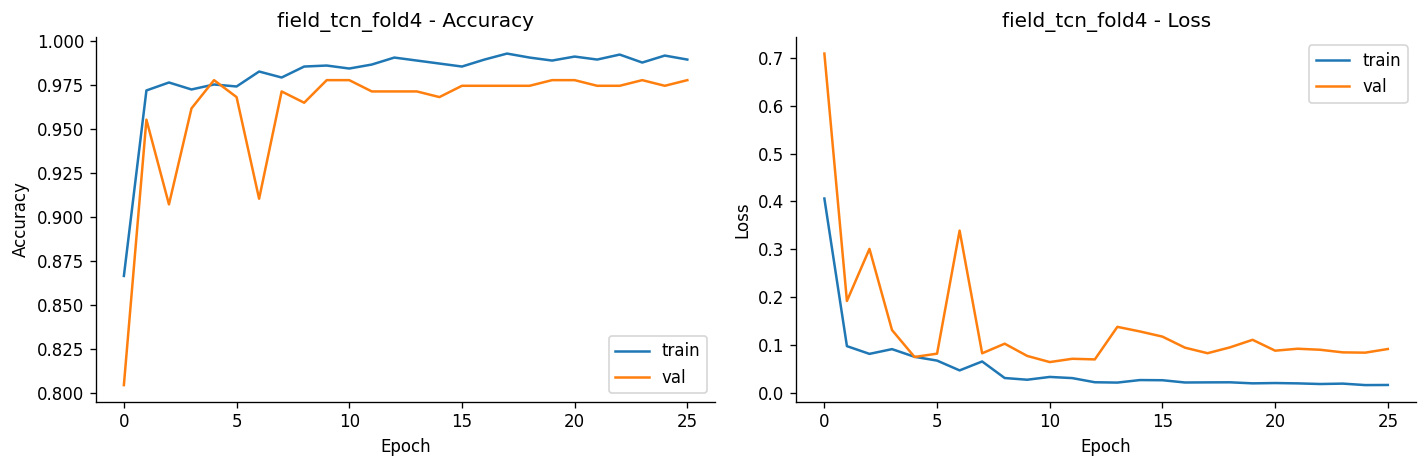


Training LSTM (fold 4)...
Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.5014 - loss: 1.2262 - val_accuracy: 0.7212 - val_loss: 0.6971 - learning_rate: 0.0010
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.6904 - loss: 0.8456 - val_accuracy: 0.7500 - val_loss: 0.7143 - learning_rate: 0.0010
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7940 - loss: 0.6106 - val_accuracy: 0.8429 - val_loss: 0.4279 - learning_rate: 0.0010
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.8353 - loss: 0.4782 - val_accuracy: 0.8910 - val_loss: 0.3425 - learning_rate: 0.0010
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9219 - loss: 0.2901 - val_accuracy: 0.9295 - val_loss: 0.2460 - learning_rate: 0.0010
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.8472 - loss: 0.4364 - val_accuracy: 0.8654 - val_loss: 0.3382 - learning_rate: 0.0010
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.87

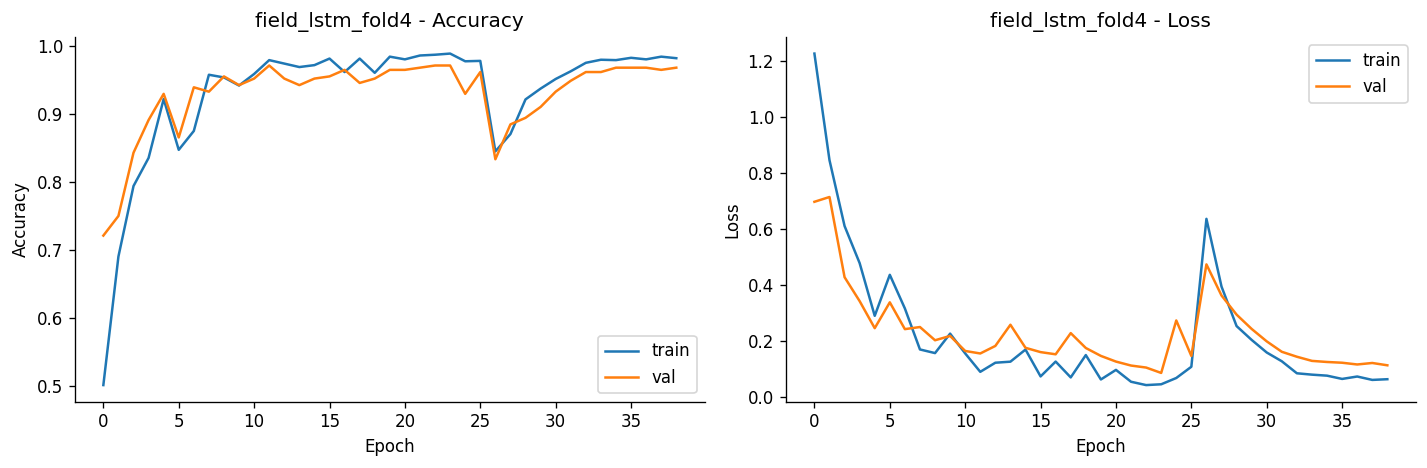


Training CNN_LSTM (fold 4)...
Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6112 - loss: 1.2144 - val_accuracy: 0.7276 - val_loss: 0.8118 - learning_rate: 0.0010
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9196 - loss: 0.3576 - val_accuracy: 0.7821 - val_loss: 0.6717 - learning_rate: 0.0010
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9626 - loss: 0.1606 - val_accuracy: 0.8782 - val_loss: 0.3731 - learning_rate: 0.0010
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9723 - loss: 0.1149 - val_accuracy: 0.9583 - val_loss: 0.1874 - learning_rate: 0.0010
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9734 - loss: 0.1009 - val_accuracy: 0.9519 - val_loss: 0.1786 - learning_rate: 0.0010
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9723 - loss: 0.1802 - val_accuracy: 0.9423 - val_loss: 0.2299 - learning_rate: 0.0010
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 

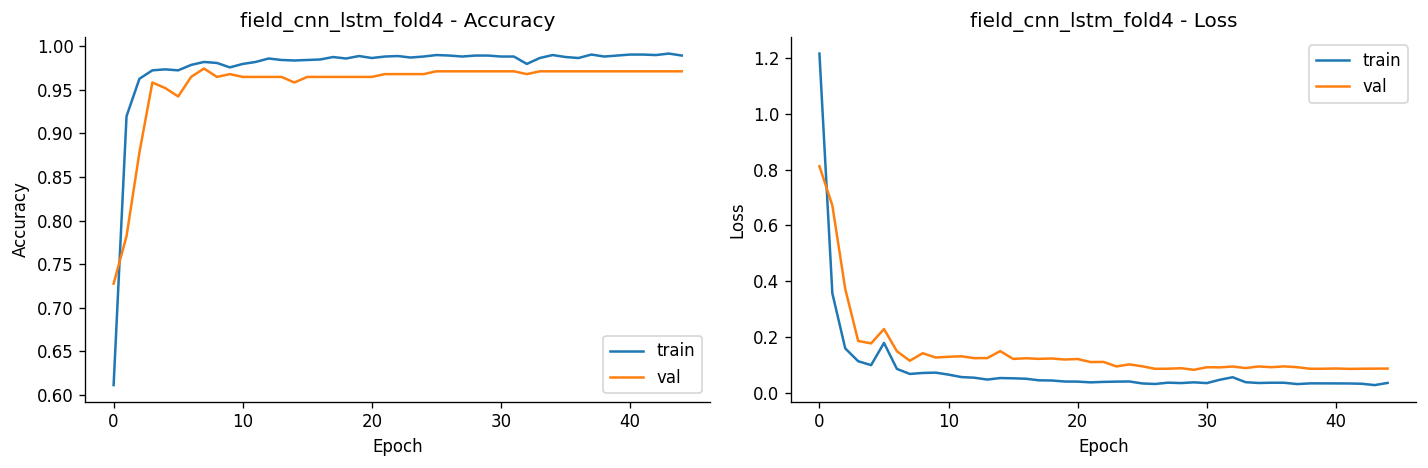


Mixed-LOSO fold 5/5: test participants=[np.str_('imaan'), np.str_('richard')]
Train samples: 2121, Test samples: 512
  Class weights: {np.str_('elliptical'): '0.50', np.str_('lat_pull'): '1.04', np.str_('lunge'): '4.24', np.str_('row'): '1.43', np.str_('threadmill'): '0.91'}

Training TCN (fold 5)...
Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8713 - loss: 0.4704 - val_accuracy: 0.9624 - val_loss: 0.3536 - learning_rate: 0.0010
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9600 - loss: 0.1188 - val_accuracy: 0.9404 - val_loss: 0.2274 - learning_rate: 0.0010
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9689 - loss: 0.0827 - val_accuracy: 0.9749 - val_loss: 0.0900 - learning_rate: 0.0010
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9678 - loss: 0.0754 - val_accuracy: 0.9843 - val_loss: 0.0509 - learning_rate: 0.0010
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9772 - loss: 0.0622 - val_ac

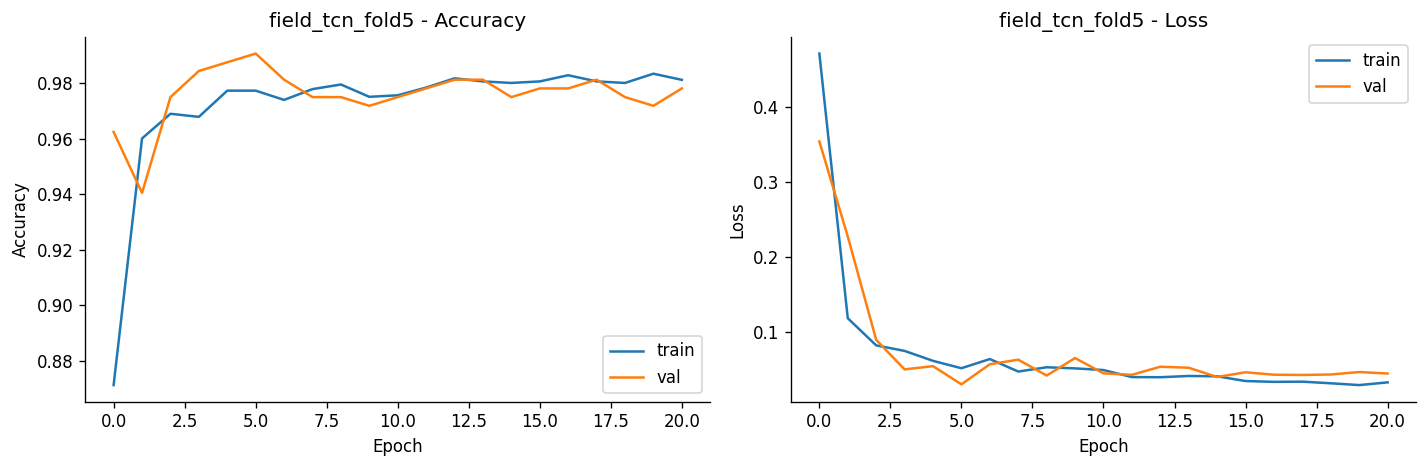


Training LSTM (fold 5)...
Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.4889 - loss: 1.2867 - val_accuracy: 0.7461 - val_loss: 0.7255 - learning_rate: 0.0010
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7481 - loss: 0.6333 - val_accuracy: 0.8433 - val_loss: 0.4009 - learning_rate: 0.0010
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.7952 - loss: 0.5927 - val_accuracy: 0.8527 - val_loss: 0.3998 - learning_rate: 0.0010
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.7825 - loss: 0.6379 - val_accuracy: 0.8495 - val_loss: 0.4245 - learning_rate: 0.0010
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8424 - loss: 0.4140 - val_accuracy: 0.9530 - val_loss: 0.2356 - learning_rate: 0.0010
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9395 - loss: 0.2482 - val_accuracy: 0.9530 - val_loss: 0.1603 - learning_rate: 0.0010
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.95

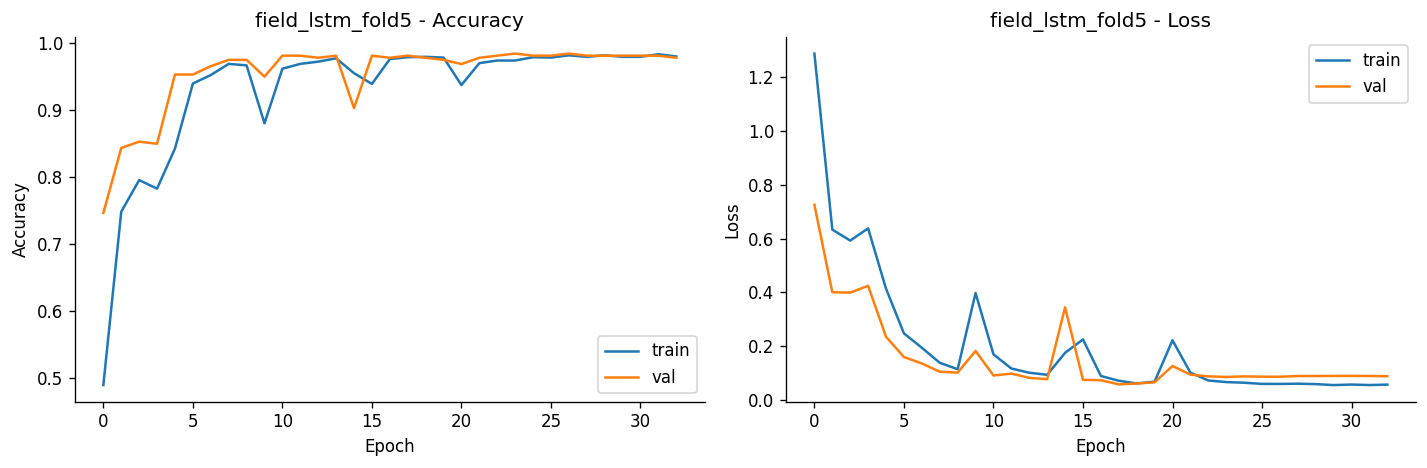


Training CNN_LSTM (fold 5)...
Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5327 - loss: 1.1528 - val_accuracy: 0.5705 - val_loss: 1.0696 - learning_rate: 0.0010
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9290 - loss: 0.2949 - val_accuracy: 0.7962 - val_loss: 0.8467 - learning_rate: 0.0010
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9567 - loss: 0.1500 - val_accuracy: 0.8871 - val_loss: 0.4992 - learning_rate: 0.0010
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9528 - loss: 0.1678 - val_accuracy: 0.8966 - val_loss: 0.5616 - learning_rate: 0.0010
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9634 - loss: 0.1301 - val_accuracy: 0.9781 - val_loss: 0.0802 - learning_rate: 0.0010
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9739 - loss: 0.0887 - val_accuracy: 0.9843 - val_loss: 0.0791 - learning_rate: 0.0010
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 

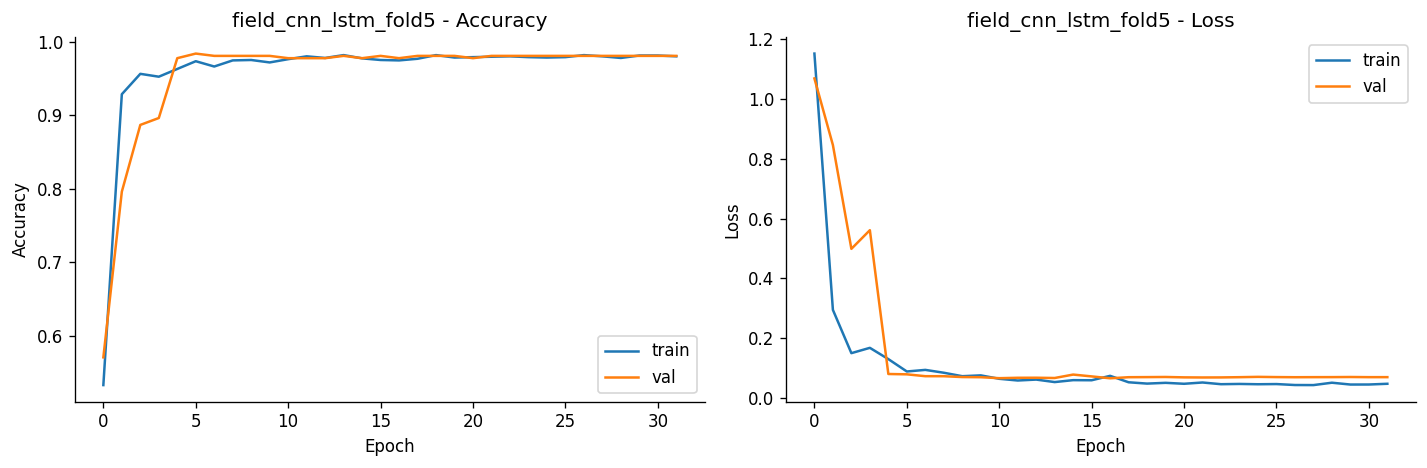


Mixed-LOSO Summary
  TCN       : per_fold=['0.9638', '0.9582', '0.9847', '0.9747', '0.9980']  ->  Mean = 0.9759
  LSTM      : per_fold=['0.9654', '0.9542', '0.9803', '0.9693', '0.9902']  ->  Mean = 0.9719
  CNN_LSTM  : per_fold=['0.9671', '0.9462', '0.9847', '0.9693', '0.9941']  ->  Mean = 0.9723


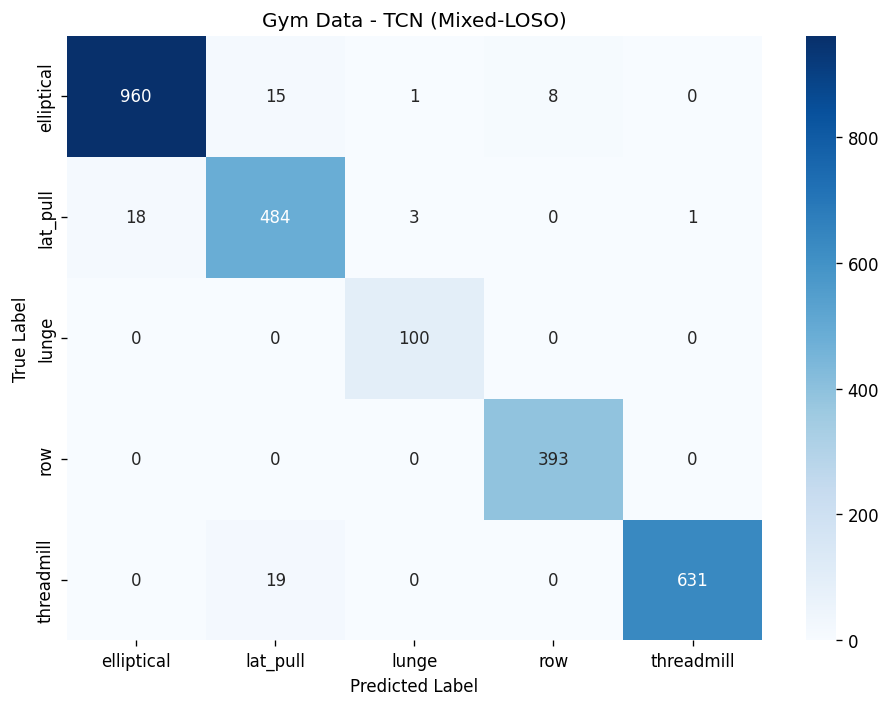

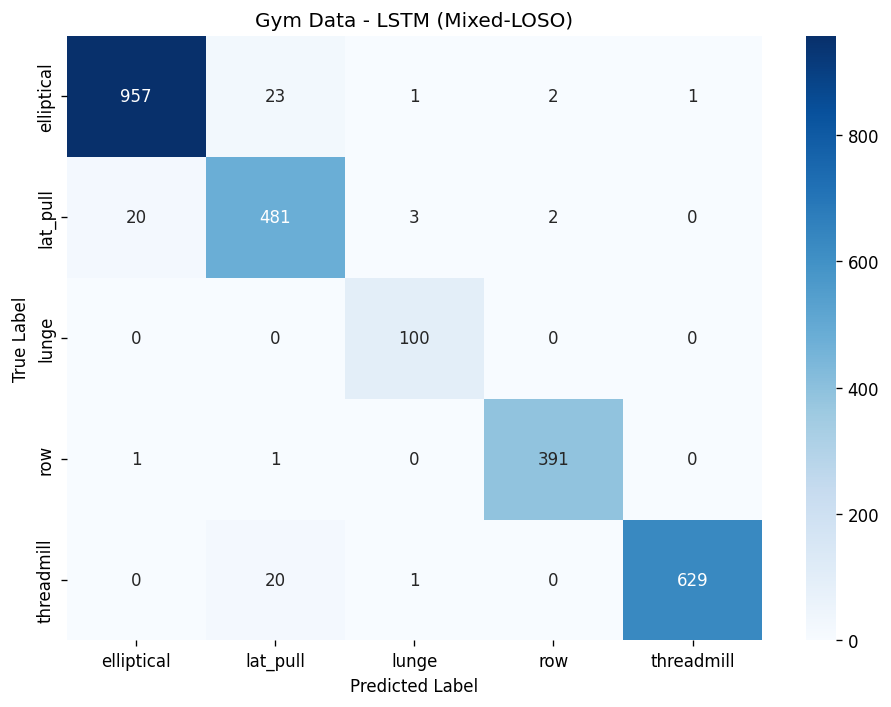

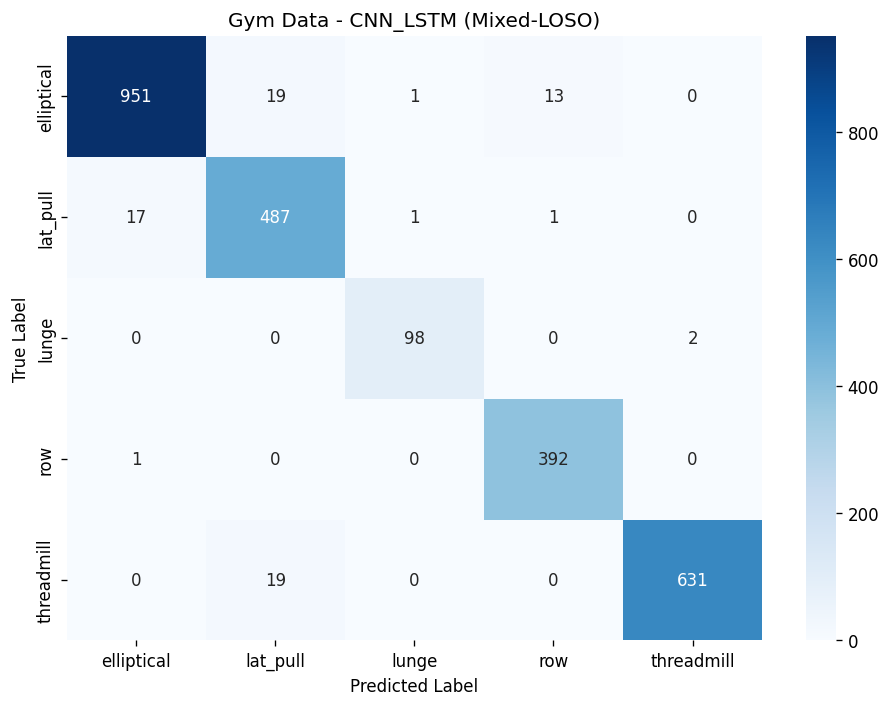

In [6]:
# ── 5. MIXED-LOSO DL TRAINING ─────────────────────────────────────────────────
# Each of the 5 folds holds out ~1/5 of sessions from BOTH participants,
# so train and test always contain a mix of imaan (smartwatch) + richard (iPhone).
# Class weights prevent majority-class collapse.

import os
os.makedirs("./Models/Gym Models", exist_ok=True)
os.makedirs("./Plots", exist_ok=True)

dl_results, dl_summary = pipeline.evaluate_loso(
    sequences, labels, participants, sessions,
    model_types=("tcn", "lstm", "cnn_lstm"),
    k=5,
    epochs=50,
    batch_size=32,
    optimize=False,
    save_dir="./Models/Gym Models",
    plots_dir="./Plots",
)

=== Deep Learning Mixed-LOSO Summary ===
Model          Mean Acc Per-fold accuracies
------------------------------------------------------------
TCN              0.9759  [0.964  0.958  0.985  0.975  0.998]
LSTM             0.9719  [0.965  0.954  0.980  0.969  0.990]
CNN_LSTM         0.9723  [0.967  0.946  0.985  0.969  0.994]

=== TCN – Classification Report ===
              precision    recall  f1-score   support

  elliptical       0.98      0.98      0.98       984
    lat_pull       0.93      0.96      0.95       506
       lunge       0.96      1.00      0.98       100
         row       0.98      1.00      0.99       393
  threadmill       1.00      0.97      0.98       650

    accuracy                           0.98      2633
   macro avg       0.97      0.98      0.98      2633
weighted avg       0.98      0.98      0.98      2633



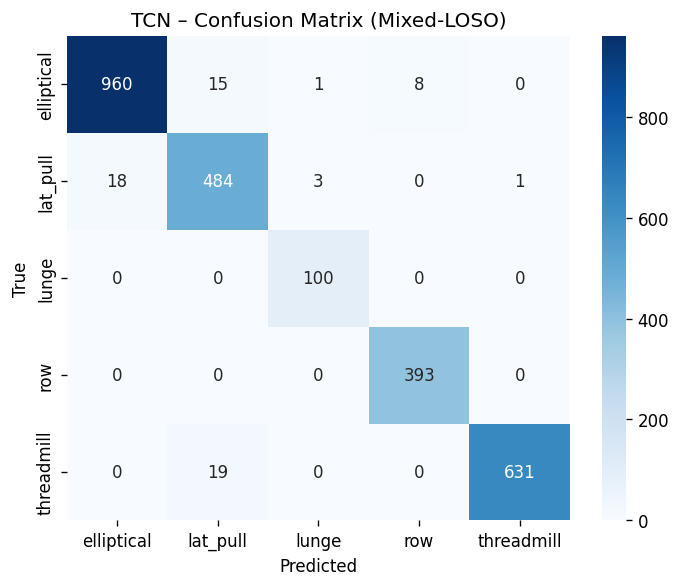


=== LSTM – Classification Report ===
              precision    recall  f1-score   support

  elliptical       0.98      0.97      0.98       984
    lat_pull       0.92      0.95      0.93       506
       lunge       0.95      1.00      0.98       100
         row       0.99      0.99      0.99       393
  threadmill       1.00      0.97      0.98       650

    accuracy                           0.97      2633
   macro avg       0.97      0.98      0.97      2633
weighted avg       0.97      0.97      0.97      2633



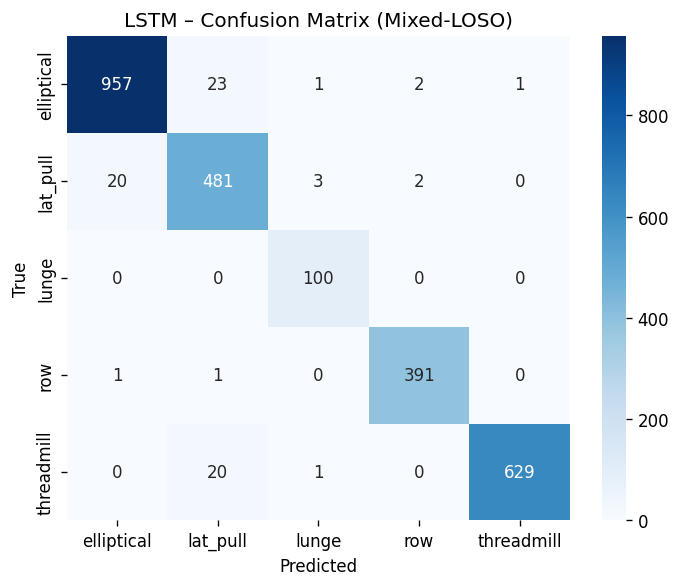


=== CNN_LSTM – Classification Report ===
              precision    recall  f1-score   support

  elliptical       0.98      0.97      0.97       984
    lat_pull       0.93      0.96      0.94       506
       lunge       0.98      0.98      0.98       100
         row       0.97      1.00      0.98       393
  threadmill       1.00      0.97      0.98       650

    accuracy                           0.97      2633
   macro avg       0.97      0.98      0.97      2633
weighted avg       0.97      0.97      0.97      2633



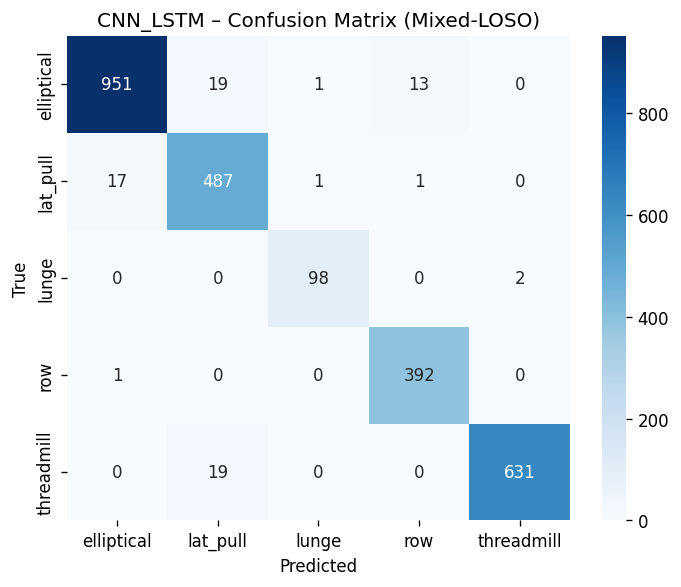

In [7]:
# ── 6. RESULTS SUMMARY ────────────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("=== Deep Learning Mixed-LOSO Summary ===")
print(f"{'Model':<12} {'Mean Acc':>10} {'Per-fold accuracies'}")
print("-" * 60)
for mt, s in dl_summary.items():
    folds = "  ".join(f"{a:.3f}" for a in s["per_fold"])
    print(f"{mt.upper():<12} {s['mean']:>10.4f}  [{folds}]")

# Per-model confusion matrix (all folds combined)
activities = sorted(set(labels))
for mt in dl_summary:
    y_true_all, y_pred_all = [], []
    for fk in dl_results:
        y_true_all.extend(dl_results[fk][mt]["y_true"])
        y_pred_all.extend(dl_results[fk][mt]["y_pred"])

    print(f"\n=== {mt.upper()} – Classification Report ===")
    print(classification_report(y_true_all, y_pred_all, target_names=activities, zero_division=0))

    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_true_all, y_pred_all, labels=activities)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=activities, yticklabels=activities, ax=ax)
    ax.set_title(f"{mt.upper()} – Confusion Matrix (Mixed-LOSO)")
    ax.set_ylabel("True")
    ax.set_xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(f"./Plots/dl_{mt}_confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()

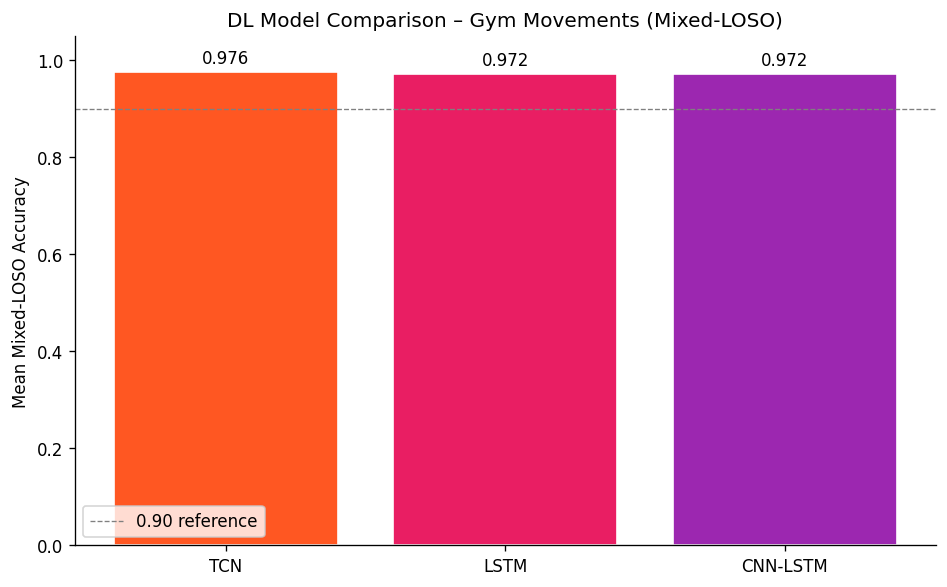

In [8]:
# ── 7. MODEL COMPARISON BAR CHART ────────────────────────────────────────────
from matplotlib.patches import Patch

model_labels = {"tcn": "TCN", "lstm": "LSTM", "cnn_lstm": "CNN-LSTM"}
names  = [model_labels.get(mt, mt.upper()) for mt in dl_summary]
means  = [dl_summary[mt]["mean"] for mt in dl_summary]
colors = ["#FF5722", "#E91E63", "#9C27B0"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, means, color=colors, edgecolor="white")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Mean Mixed-LOSO Accuracy")
ax.set_title("DL Model Comparison – Gym Movements (Mixed-LOSO)")
ax.axhline(0.9, color="gray", linestyle="--", linewidth=0.8, label="0.90 reference")
ax.legend()

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("./Plots/dl_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()